In [32]:

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import SamplerV2
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.circuit.library import HalfAdderGate
from qiskit.synthesis import adder_ripple_c04
from dotenv import load_dotenv
import os
load_dotenv()

QiskitRuntimeService.save_account(
    token=os.getenv("IBM_QUANTUM_API_KEY"),
    overwrite=True
)

from qiskit.transpiler import generate_preset_pass_manager

service = QiskitRuntimeService()
backend = service.least_busy(simulator=False, operational=True)
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)

sv_sampler = StatevectorSampler(default_shots=2)
backend_sampler = SamplerV2(mode=backend)

qiskit_runtime_service.__init__:WARNING:2026-04-17 15:40:27,299: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-17 15:40:27,894: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-17 15:40:29,599: Using instance: open-instance, plan: open


In [22]:
def extract_state(qc) -> str:
    state = Statevector.from_instruction(qc)
    return str(list(state.probabilities_dict().keys())[0]) # Simulation is exact

# Test rigurously
def get_answer(circuit, a_val, a_reg, b_val, b_reg, all_regs, qubits, answer_ranges):
    qc = QuantumCircuit(*all_regs)
    for i in range(4):
        if (a_val >> i) & 1:
            qc.x(a_reg[i])
        if (b_val >> i) & 1:
            qc.x(b_reg[i])
    print(f"Initial state: {extract_state(qc)}")
    qc.append(circuit, qubits)
    bitstr = extract_state(qc)
    print(f"Final state:   {bitstr}")
    return tuple(int(bitstr[a_range[0]:a_range[1]], 2) for a_range in answer_ranges)

# Multiplier
[Quantum Circuit Design for Integer Multiplication Based on Schönhage–Strassen Algorithm | IEEE Journals & Magazine | IEEE Xplore](https://ieeexplore-ieee-org.uprm.idm.oclc.org/document/10138719)

$a_0 B + a_1 2B + a_2 2^2B + a_3 2^3B$ for $n = 4$

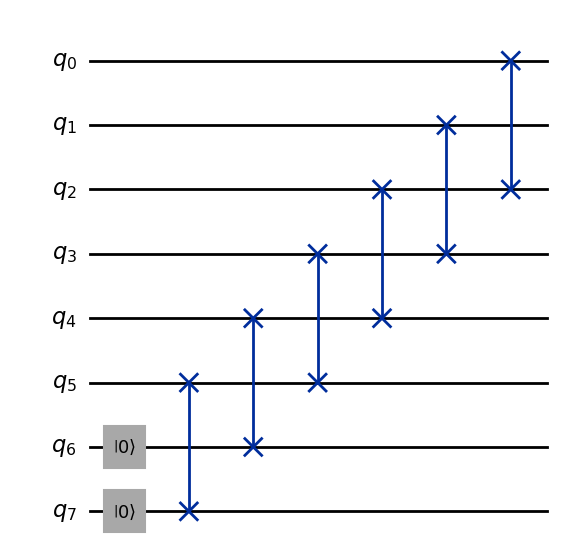

In [2]:
# I just realized this is completely unnecesary but I'll leave it here anyways
def shift_left(num_qubits, shift_amount) -> QuantumCircuit:
    """Shift left by shift_amount. (Non-circular)"""
    qc = QuantumCircuit(num_qubits, name=f"shift_left_{shift_amount}")
    for i in range(num_qubits - shift_amount, num_qubits):
        qc.reset(qc.qubits[i])
    for i in range(num_qubits - 1, shift_amount -1, -1):
        qc.swap(qc.qubits[i], qc.qubits[i - shift_amount])
    return qc

shift_left(8, 2).draw(output="mpl")

## n = 3

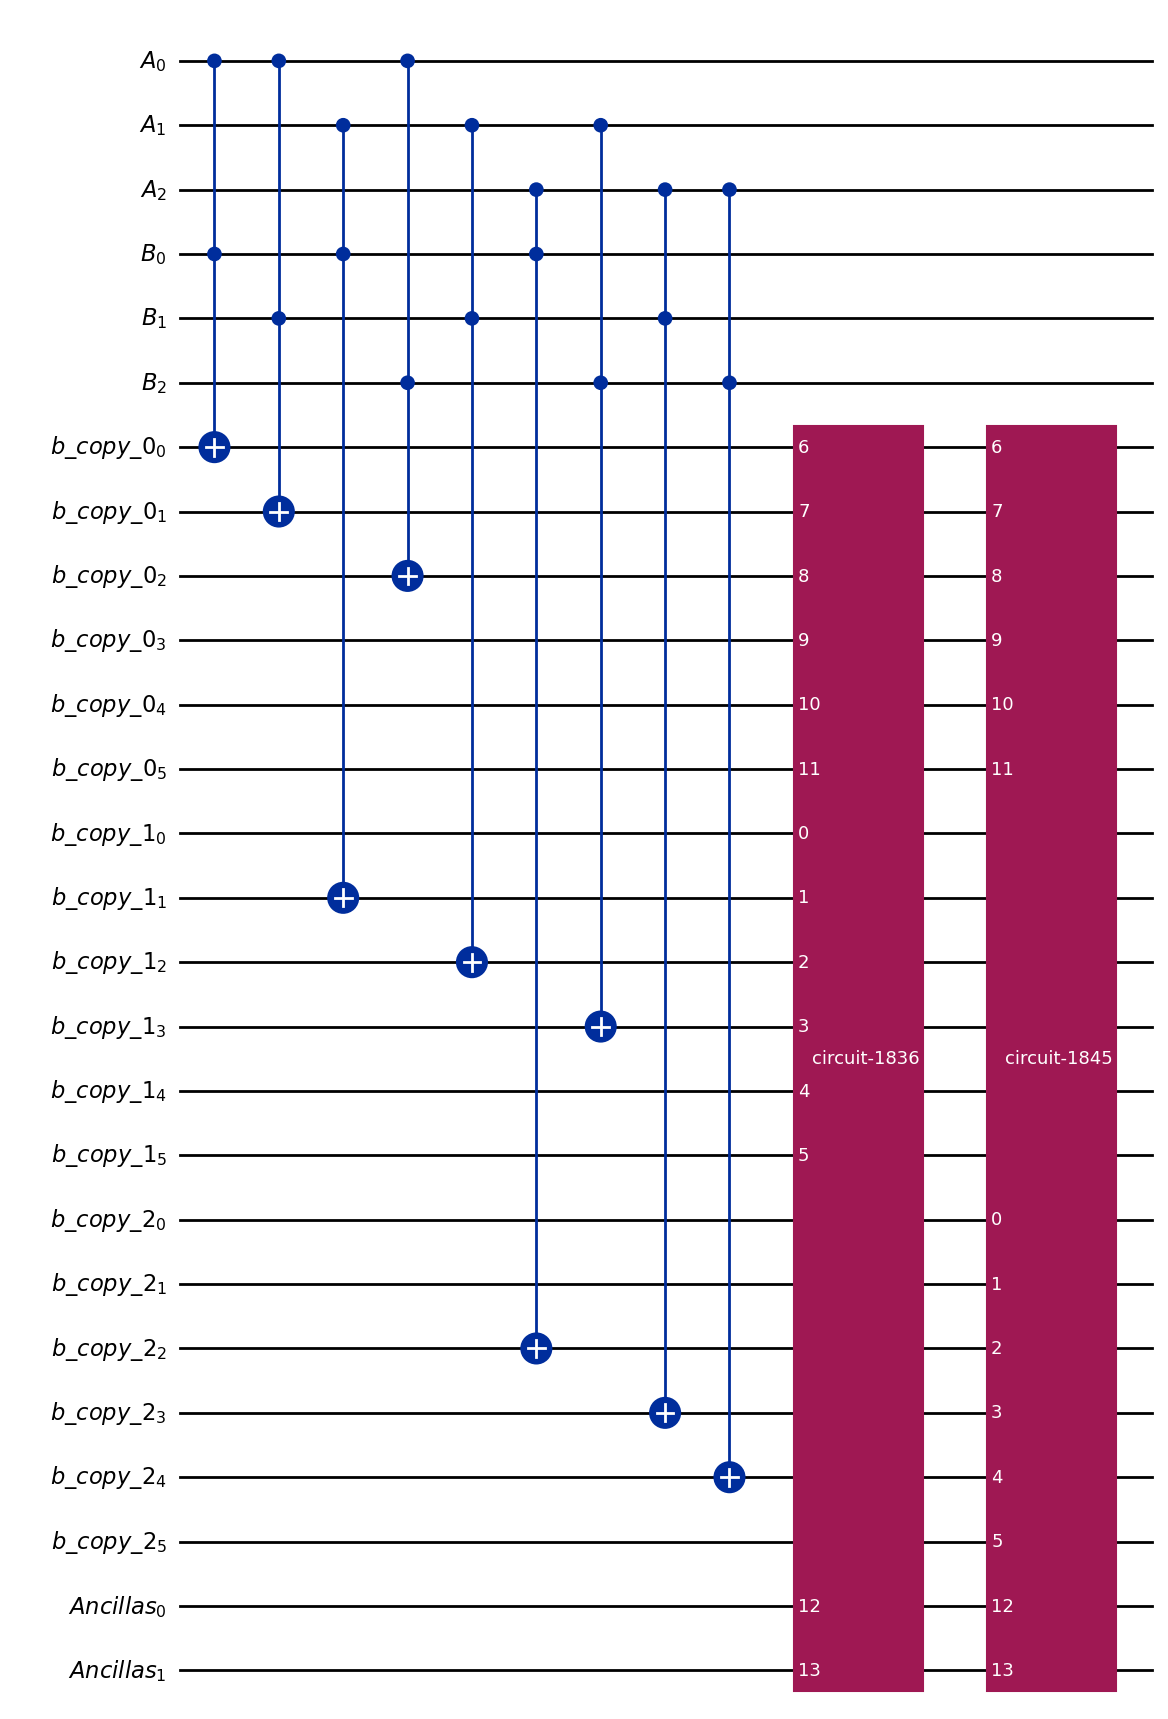

In [24]:
# Build the circuit
# b_0 will hold the final product

n = 3
a = QuantumRegister(n, name="A")
b = QuantumRegister(n, name="B")
b_copies = [QuantumRegister(n*2, name=f"b_copy_{i}") for i in range(n)]
ancs  = QuantumRegister(2, name="Ancillas")  # For the half adder
# for some strange and convoluted reason, calling your register "ancilla" raises "list index out of range" when running on ibm
meas = ClassicalRegister(n*2, name="meas")

mult_qc = QuantumCircuit(a, b, *b_copies, ancs)

# Copy b 4 times and shift each copy
for i in range(n):
    for j in range(n):
        mult_qc.ccx(a[i], b[j], b_copies[i][j+i])
        # Also shift while we're at it
        # Also AND with A while we're at it

# Add the shifted copies together
# cuccaro to the rescue
mult_qc.append(adder_ripple_c04(n*2), list(b_copies[1]) + list(b_copies[0]) + list(ancs))
mult_qc.append(adder_ripple_c04(n*2), list(b_copies[2]) + list(b_copies[0]) + list(ancs))

mult_qc.draw(output="mpl")

In [27]:
start_first_copy = 2 + (2*n)*(n-1)
"00000000000110001001011011"[start_first_copy:start_first_copy + 2*n]

'001001'

In [29]:
# Test multiplier
start_first_copy = 2 + (2*n)*(n-1)
for a_val in range(2**n):
    for b_val in range(2**n):
        answer = get_answer(mult_qc, a_val, a, b_val, b, [a, b] + b_copies + [ancs], mult_qc.qubits, [(start_first_copy, start_first_copy + 2*n)])
        print(f"{a_val} * {b_val} = {answer[0]} (expected {a_val * b_val})", "WRONG" if answer[0] != a_val * b_val else "")

Initial state: 00000000000000000000000000
Final state:   00000000000000000000000000
0 * 0 = 0 (expected 0) 
Initial state: 00000000000000000000001000
Final state:   00000000000000000000001000
0 * 1 = 0 (expected 0) 
Initial state: 00000000000000000000010000
Final state:   00000000000000000000010000
0 * 2 = 0 (expected 0) 
Initial state: 00000000000000000000011000
Final state:   00000000000000000000011000
0 * 3 = 0 (expected 0) 
Initial state: 00000000000000000000100000
Final state:   00000000000000000000100000
0 * 4 = 0 (expected 0) 
Initial state: 00000000000000000000101000
Final state:   00000000000000000000101000
0 * 5 = 0 (expected 0) 
Initial state: 00000000000000000000110000
Final state:   00000000000000000000110000
0 * 6 = 0 (expected 0) 
Initial state: 00000000000000000000111000
Final state:   00000000000000000000111000
0 * 7 = 0 (expected 0) 
Initial state: 00000000000000000000000001
Final state:   00000000000000000000000001
1 * 0 = 0 (expected 0) 
Initial state: 0000000000000

KeyboardInterrupt: 

In [28]:
get_answer(mult_qc, 3, a, 3, b, [a, b] + b_copies + [ancs], mult_qc.qubits, [(start_first_copy, start_first_copy + 2*n)])

Initial state: 00000000000000000000011011
Final state:   00000000000110001001011011


(9,)

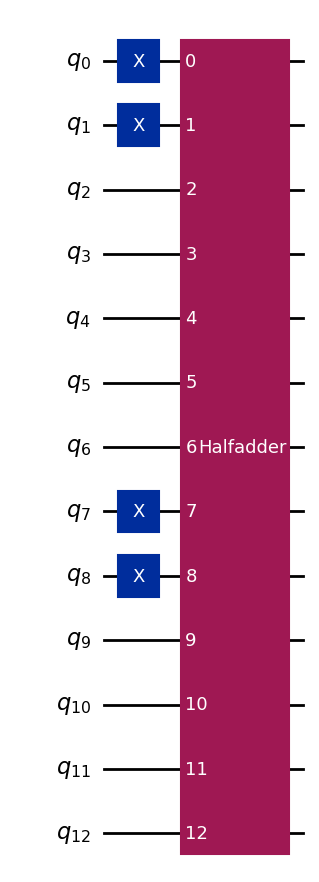

In [19]:
# man boy what the hellll
test_adder = QuantumCircuit(13)
test_adder.x(0)
test_adder.x(1)
test_adder.x(7)
test_adder.x(8)
test_adder.append(HalfAdderGate(6), list(range(6)) + list(range(6, 12)) + [12])
test_adder.draw(output="mpl")

In [20]:
extract_state(test_adder)
# OH MY FUCKING GOD WHY

'0000001000011'

In [37]:
job_qc = QuantumCircuit(a, b, *b_copies, ancs, meas)
job_qc.x(a[0])
job_qc.x(a[1])
job_qc.x(b[0])
job_qc.x(b[1])
job_qc.append(mult_qc, job_qc.qubits)
job_qc.measure(b_copies[0], meas)
sv_sampler.run([job_qc]).result()[0].data.meas.get_counts()

{'001001': 2}

In [36]:
backend_sampler.options.default_shots = 2**(n*5)
isa_circuit_mult_qiskit = pm.run(job_qc)
job = backend_sampler.run([isa_circuit_mult_qiskit])
print(f">>> Job ID: {job.job_id()}")

>>> Job ID: d7h8qu22khts739pfgpg


{'101010': 833, '101110': 814, '100110': 780, '101111': 776, '110010': 748, '111010': 723, '100010': 722, '110110': 719, '100111': 699, '111110': 676}
Number of keys: 64
Number of shots: 32768
Expected result 001001: 431
Probability: 0.0132


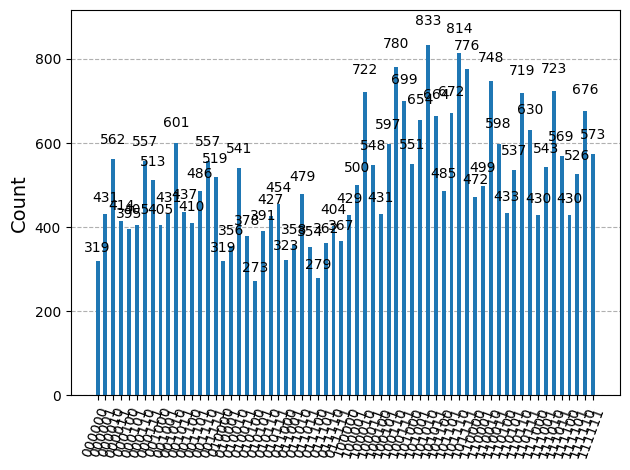

In [39]:
result = job.result()[0]
counts = result.data.meas.get_counts()
# Get top 5 results
top = dict(sorted(counts.items(), key=lambda item: item[1], reverse=True)[:10])
print(top)
num_shots = sum(counts.values())
print("Number of keys:", len(counts))
print("Number of shots:", num_shots)
expected = '001001'
print(f"Expected result {expected}: {counts[expected]}")
print(f"Probability: {counts[expected] / num_shots:.4f}")
plot_histogram(counts)

## n = 4

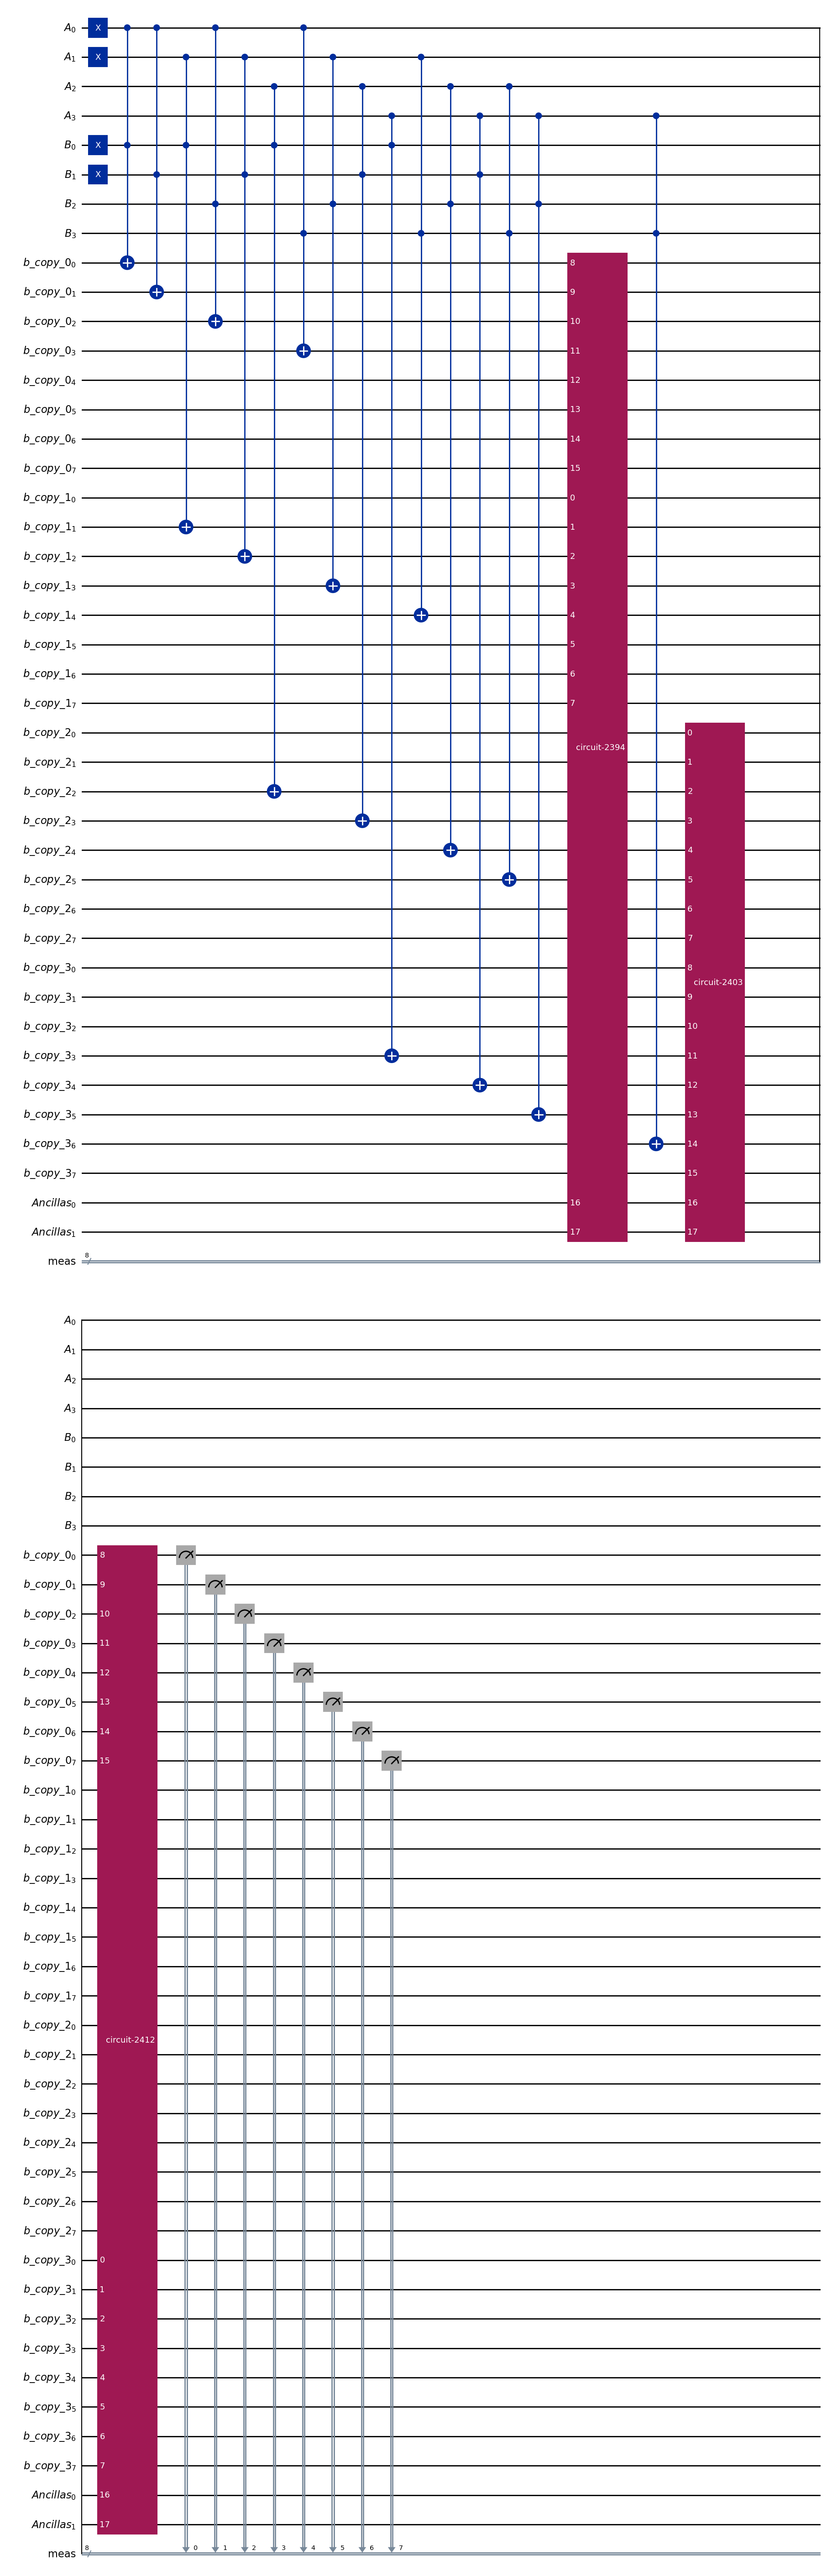

In [46]:
# Build the circuit
# b_0 will hold the final product

n = 4
a = QuantumRegister(n, name="A")
b = QuantumRegister(n, name="B")
b_copies = [QuantumRegister(n*2, name=f"b_copy_{i}") for i in range(n)]
# for some strange and convoluted reason, calling your register "ancilla" raises "list index out of range" when running on ibm
meas = ClassicalRegister(n*2, name="meas")

mult_qc = QuantumCircuit(a, b, *b_copies, ancs, meas)

# Set
mult_qc.x(a[0])
mult_qc.x(a[1])
mult_qc.x(b[0])
mult_qc.x(b[1])

# Copy b 4 times and shift each copy
for i in range(n):
    for j in range(n):
        mult_qc.ccx(a[i], b[j], b_copies[i][j+i])
        # Also shift while we're at it
        # Also AND with A while we're at it

# Add the shifted copies together

mult_qc.append(adder_ripple_c04(n*2), list(b_copies[1]) + list(b_copies[0]) + list(ancs))
mult_qc.append(adder_ripple_c04(n*2), list(b_copies[2]) + list(b_copies[3]) + list(ancs))
mult_qc.append(adder_ripple_c04(n*2), list(b_copies[3]) + list(b_copies[0]) + list(ancs))

mult_qc.measure(b_copies[0], meas)  # b_copy_0 holds the final product
mult_qc.draw(output="mpl")

In [48]:
job_qc = mult_qc
sv_sampler.run([job_qc]).result()[0].data.meas.get_counts()

MemoryError: Unable to allocate 64.0 TiB for an array with shape (2, 2199023255552) and data type complex128

In [49]:
backend_sampler.options.default_shots = 2**(n*5)
isa_circuit_mult_qiskit = pm.run(job_qc)
job = backend_sampler.run([isa_circuit_mult_qiskit])
print(f">>> Job ID: {job.job_id()}")

>>> Job ID: d7h92mvb91ec73aufepg


{'11010110': 5034, '11000110': 5032, '11110110': 5023, '11110111': 4912, '11010111': 4840, '11000111': 4812, '10010110': 4784, '11100110': 4774, '11001010': 4763, '10110110': 4728}
Number of keys: 256
Number of shots: 1048576
Expected result 00001001: 3960
Probability: 0.0038


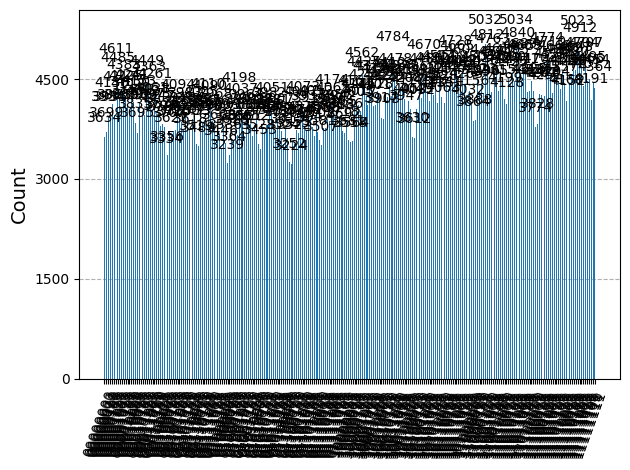

In [51]:
result = job.result()[0]
counts = result.data.meas.get_counts()
# Get top 5 results
top = dict(sorted(counts.items(), key=lambda item: item[1], reverse=True)[:10])
print(top)
num_shots = sum(counts.values())
print("Number of keys:", len(counts))
print("Number of shots:", num_shots)
expected = '00001001'
print(f"Expected result {expected}: {counts[expected]}")
print(f"Probability: {counts[expected] / num_shots:.4f}")
plot_histogram(counts)